In [1]:
import sys
import numpy as np
import anndata as ad

import src as scit
import anndata as ad
import igraph as ig

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')

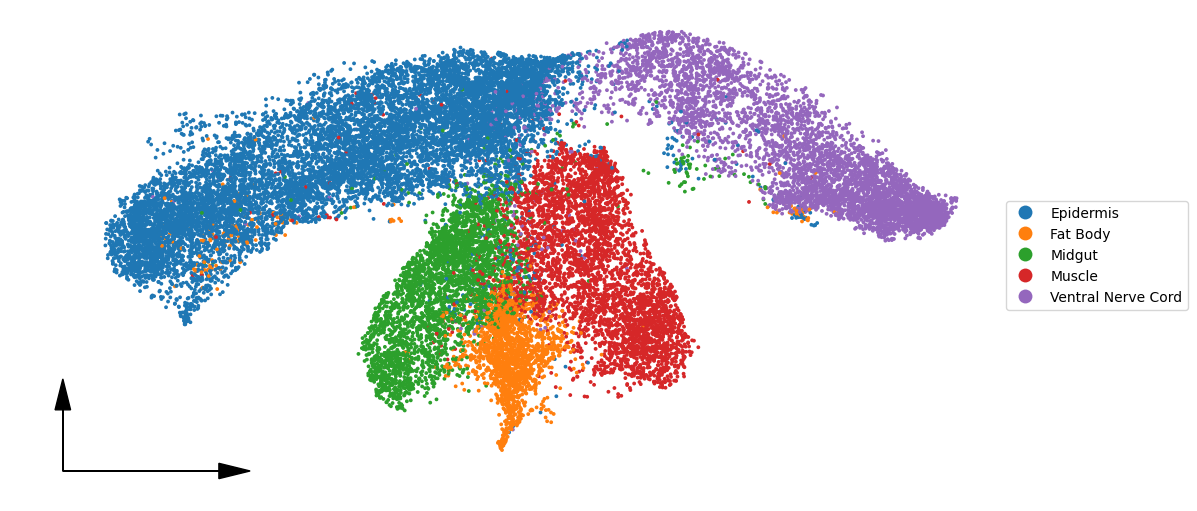

In [3]:
scit.pl.embedding2d(adata, 'X_umap', 'label')

In [4]:
insitu_n = 'BP'
obodag = scit.ld.obodag('../data/dm-stage6.obo', namespaces={'insitu': insitu_n})
ns2assoc = scit.ld.gaf('../data/stage6_gene2go.gaf', obodag)#, name_column=2)

../data/dm-stage6.obo: fmt(1.2) rel(2024-01-17) 139 Terms


In [5]:
pre_imp_acet = scit.tl.make_layer_config('acet', in_obsm=True, log_transform=False, normalize_with_obs_counts=True, feature_names=adata.uns['gene_names_acet_imp'])

godag_v = list([d.name for d in obodag.godag.values()])
print(godag_v)
# tm = 'epidermis'
# assert tm in godag_v
# include_gos = [tm]
include_gos = godag_v

scit.tl.go_infer_layer(adata, pre_imp_acet.feature_names, obodag, ns2assoc, include_gos, lc=pre_imp_acet, return_matrix=False)
adata.obsm['go_term'].data = adata.obsm['go_term'].data**0.5
# lc_go = scit.tl.make_layer_config('go_term', in_obsm=True, feature_names=adata.uns['gene_names_go_term'])

['Malpighian tubule', 'amnioserotic', 'anal pad', 'apodeme', 'blood', 'brain', 'circulatory system', 'epidermis', 'eye', 'fat body', 'foregut', 'germ cells', 'gland', 'gonads', 'head', 'hindgut', 'imaginal', 'midgut', 'muscle', 'nephrocyte', 'nervous system', 'oenocyte', 'segment', 'sensory organ', 'trachea', 'yolk', 'adult clypeo-labral primordium', 'adult eye primordium', 'adult foregut precursor', 'adult hindgut precursor', 'adult midgut precursor', 'adult muscle precursor primordium', 'adult salivary primordium', 'amnioserosa', 'apoptotic amnioserosa', 'circular visceral muscle fibers', 'clypeolabrum', 'crystal cell', 'dorsal histoblast nest abdominal', 'dorsal imaginal precursor', 'dorsal prothoracic pharyngeal muscle', 'dorsal/lateral sensory complexes', "embryonic Bolwig's organ", 'embryonic Malpighian tubule', 'embryonic Malpighian tubule tip cell', 'embryonic anal pad', 'embryonic antennal sense organ', 'embryonic brain', 'embryonic central brain', 'embryonic central brain gli

In [28]:
scit.set_defaults(figsize=(3,2))
lc_go = scit.tl.make_layer_config('go_term', in_obsm=True, log_transform=False, normalize_with_obs_counts=False, feature_names=adata.uns['gene_names_go_term'])


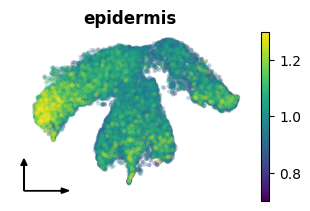

In [29]:
tm = 'epidermis'
scit.tl.layer_pick_features(adata, lc_go, f'{tm}_{insitu_n}')
scit.tl.copy_to_obs(adata, lc_go)
_vm = (0.7, 1.3)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=5, alpha=0.2, black_background=False, title=tm, show=True, vminmax=_vm)#.savefig(f'private/newest/figures/smallanatomic/{tm}.pdf')

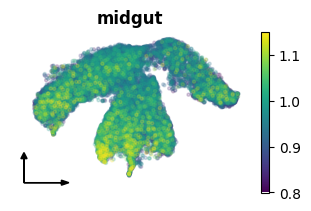

In [58]:
tm = 'midgut'
scit.tl.layer_pick_features(adata, lc_go, f'{tm}_{insitu_n}')
scit.tl.copy_to_obs(adata, lc_go)
_vm = (0.8, 1.15)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=5, alpha=0.2, black_background=False, title=tm, show=True, vminmax=_vm)#.savefig(f'private/newest/figures/smallanatomic/{tm}.pdf')

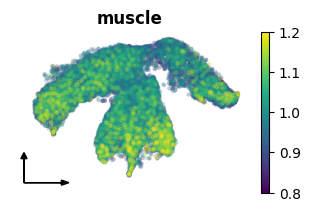

In [60]:
tm = 'muscle'
scit.tl.layer_pick_features(adata, lc_go, f'{tm}_{insitu_n}')
scit.tl.copy_to_obs(adata, lc_go)
_vm = (0.8, 1.2)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=5, alpha=0.2, black_background=False, title=tm, show=True, vminmax=_vm)#.savefig(f'private/newest/figures/smallanatomic/{tm}.pdf')

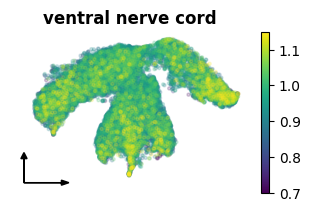

In [75]:
tm = 'ventral nerve cord'
scit.tl.layer_pick_features(adata, lc_go, f'{tm}_{insitu_n}')
scit.tl.copy_to_obs(adata, lc_go)
_vm = (0.7, 1.15)
scit.pl.embedding2d(adata, 'X_umap', 'copied_data', size=5, alpha=0.2, black_background=False, title=tm, show=True, vminmax=_vm)#.savefig(f'private/newest/figures/smallanatomic/{tm}.pdf')